DSC530: Week 12 \
12.2 Exercise \
Marty Hoehler \
6-1-24 

# Exercise 12-2 - Term Project

### 1.  Selecting Data

The Home Mortgage Disclosure Act (HMDA: https://ffiec.cfpb.gov/) "requires many financial institutions to maintain, report, and publicly disclose information about mortgages."  The 2023 data was released in March of 2024, and gives us the opportunity to analyze a large data set of mortgages that occured in the US in 2023.

One field that was newly added to the HMDA data set was a boolean for whether the applicant was over the age of 62.  They've always included age of applicant in the data, but the inclusion of this specific boolean made me curious.  Just how different are the borrowing tendencies of "elder applicants" (over 62) compared to "younger applicants" (under 62).  

#### Hypothesis:
I would hypothesize that elder applicants might be "moving down" in house, and so you might see lower property values for this cohort.  I would also hypothesize that elder applicants might be cashing in on equity when they move out of their current house, and that we might see correspondingly lower loan amounts, compared to younger applicants.

We begin our data exploration with our usual library imports and download function.

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)  

download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/thinkstats2.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/thinkplot.py")
import thinkstats2
import thinkplot

import numpy as np
import pandas as pd        

THe HMDA data set (called the "Modified Loan/Application Register (LAR)" is stored as a text file within a zip file.  I used the following sources to modify the pd.read_csv() function appropriately:
https://www.geeksforgeeks.org/reading-specific-columns-of-a-csv-file-using-pandas/
https://stackoverflow.com/questions/24251219/pandas-read-csv-low-memory-and-dtype-options)

Data Dictionary from HMDA:
https://ffiec.cfpb.gov/documentation/publications/modified-lar/modified-lar-schema

In [2]:
zf = 'https://s3.amazonaws.com/cfpb-hmda-public/prod/dynamic-data/combined-mlar/2023/header/2023_combined_mlar_header.zip'

df = pd.read_csv(zf, sep = '|', na_values = "NA", usecols=['activity_year', 'loan_purpose', 'occupancy_type', 
                                        'loan_amount', 'action_taken', 
                                        'applicant_sex', 'applicant_age',
                                        'applicant_age_above_62', 'income', 'combined_loan_to_value_ratio', 
                                        'loan_term', 'property_value'],
                dtype={"activity_year": int, "loan_purpose": int, "occupancy_type": int, 
                      "loan_amount": int, "action_taken": int,  
                       "applicant_sex": int, "applicant_age": str, "applicant_age_above_62": str, "income": float,
                      "combined_loan_to_value_ratio": str, "loan_term": str, "property_value": str}) 



### 2. Description of variables:

- Activity Year: (int) This should be 2023 for all values.
- Loan Purpose: (int) We will filter this to "1" for Home Purchases only.  (Excluding Home improvements, refinancing, etc.)
- Occupancy Type: (int)  We will filter this to "1" for Principle residence only.  (Excluding second residences, investment propeties, etc.)
- Loan Amount: (int)  The dollar amount of the loan rounded to the nearest \\$10,000.
- Action taken: (int) We will be primarily interested in loans that went through to completion and were originated (1).  
    - (Other examples: Application denied (3), Application withdrawn by applicant (4), etc.)
- Sex of Applicant: (int) 1 = Male, 2 = Female, 3= Information not provided, 4 = NA, 5 (not uesd), 6 = Both
- Age of Applicant: (string)  Groups applicants into bins: >25, 25-34, 35-44, 45-54, 55-64, 65-74, >75
- Age of Applicant >= 62: (string)  "Yes", "No", "NA"
- Income: (int or NA) Income of applicant in thousands of dollars (\\$K)
- Combined Loan to Value Ratio: (string) The sum of all debt against the house, (not necessarily just this loan) vs the value of the house.  Generally a floating number, but could also have "NA" or "Exempt" values.
- Property Value: (string) The value of the property being purchased with the mortgage.  Generally an integer rounded to the nearest \\$10K.  Could also be "NA" or "Exempt".

Due to some of the binning strategies and "Exempt" values in the data, there will be some cleaning required to prepare this set for analysis.


In [3]:
# Preview of the data.  Over 11 million rows.
df

,activity_year,loan_purpose,occupancy_type,loan_amount,action_taken,applicant_sex,applicant_age,applicant_age_above_62,income,combined_loan_to_value_ratio,loan_term,property_value
0,2023,2,1,105000,3,2,55-64,No,119.0,87.376,480,365000
1,2023,4,1,155000,3,1,35-44,No,82.0,20.0,480,755000
2,2023,2,1,65000,3,1,35-44,No,77.0,74.844,480,375000
3,2023,2,1,75000,3,2,35-44,No,99.0,79.0,480,605000
4,2023,2,1,65000,3,1,45-54,No,185.0,78.462,240,655000
...,...,...,...,...,...,...,...,...,...,...,...,...
11483889,2023,2,1,355000,3,2,45-54,No,286.0,73.173,480,1025000
11483890,2023,31,1,105000,1,2,>74,Yes,79.0,16.75,480,595000
11483891,2023,2,1,125000,1,1,65-74,Yes,156.0,55.576,480,885000
11483892,2023,31,1,75000,1,1,65-74,Yes,102.0,48.286,480,955000


#### Filters

We will filter to only mortgages that that were for principal residence home purchase only.  This reduces the total record count to about 5.9 million.

Loan Purpose = 1  (Home purchases only)
Occupancy Type = 1  (Principal residence only)

In [4]:
df_filt = df[df['loan_purpose']==1]
df_filt = df_filt[df_filt['occupancy_type']==1]

In [5]:
df_filt

,activity_year,loan_purpose,occupancy_type,loan_amount,action_taken,applicant_sex,applicant_age,applicant_age_above_62,income,combined_loan_to_value_ratio,loan_term,property_value
25,2023,1,1,5000,2,1,35-44,No,NaN,100.0,360,235000
26,2023,1,1,145000,3,2,25-34,No,NaN,101.409,360,155000
27,2023,1,1,595000,3,1,45-54,No,NaN,80.0,360,735000
28,2023,1,1,385000,4,2,45-54,No,NaN,NaN,360,NaN
30,2023,1,1,5000,1,1,25-34,No,93.0,100.0,360,305000
...,...,...,...,...,...,...,...,...,...,...,...,...
11483816,2023,1,1,55000,3,2,65-74,Yes,45.0,Exempt,Exempt,Exempt
11483817,2023,1,1,65000,3,1,35-44,No,55.0,Exempt,Exempt,Exempt
11483827,2023,1,1,75000,3,2,25-34,No,110.0,Exempt,Exempt,Exempt
11483837,2023,1,1,95000,3,1,<25,No,52.0,Exempt,Exempt,Exempt


### 3. Histograms and Stats for 5 variables

#### 1. Age Histogram
First, we'll look at the age distribution of the mortgage applicants.  Because the 'applicant_age' field is a string instead of an integer, we'll need to reorder the dictionary produced by the thinkstats2.Hist() funciton.  I'll use matplotlib's function to plot the histogram instead of the texts, because it can utilize the reorderd dictionary.
(Source: https://stackoverflow.com/questions/5925731/reorder-dictionary-in-python-according-to-a-list-of-values)

In [6]:
# Removing odd age of "8888"
age_filt = df_filt[df_filt['applicant_age']!= '8888']


hist = thinkstats2.Hist(age_filt.applicant_age, label='Age of Applicant')
sort_list = ['<25', '25-34', '35-44', '45-54', '55-64', '65-74', '>74']
reordered_hist = {k: hist[k] for k in sort_list}
re_hist = thinkstats2.Hist(reordered_hist, label='Age of Applicant')

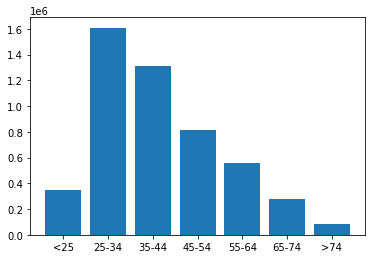

In [7]:
import matplotlib.pyplot as plt
plt.bar(range(len(reordered_hist)), list(reordered_hist.values()), align='center')
plt.xticks(range(len(reordered_hist)), list(reordered_hist.keys()))
plt.show()

This shows that the largest number of mortgage applications came from 25-34 year olds.  It will be interesting to see if this distribution changes when we look at mortgages that were completed and became originated loans.

Because the data has already been binned, you can't find precise mean, variance, etc.

#### 2. Income Histogram

The number of high-income applicants make it difficult to set bin sizes, so I'll set the range to $500,000 and under.  

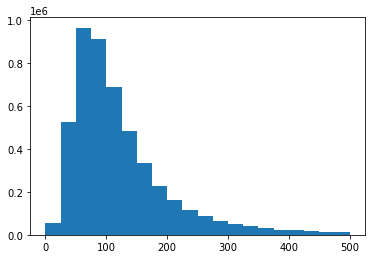

In [8]:

income_filt = age_filt[age_filt.income >0].copy(deep=True)

plt.hist(income_filt.income, bins=20, range=[0, 500])
plt.show()


This makes sense.  It shows that the sweetspot for mortgages are those with incomes between $50-125k.  We'll run the stats to get more specific information.

In [9]:
print("mean:", income_filt.income.mean(), "median:", income_filt.income.median(), "mode:", income_filt.income.mode())
print("variance:", income_filt.income.var(), "s.d.", income_filt.income.std())
print("Min:", income_filt.income.min(), "Max:", income_filt.income.max(), 
      "Interquartile Range:", np.percentile(income_filt.income, 75)-np.percentile(income_filt.income, 25))
print("Q1:", np.percentile(income_filt.income, 25), "Q3:", np.percentile(income_filt.income, 75) )

mean: 140.0262993860786 median: 100.0 mode: 0    60.0
dtype: float64
variance: 5999016.649900423 s.d. 2449.2890090596543
Min: 1.0 Max: 5004153.0 Interquartile Range: 87.0
Q1: 67.0 Q3: 154.0


We'd expect the mean (\\$140K) to be higher than the median, since we have some very high incomes in there to draw up the mean.  The median (\\$100K) is a better indicator of central tendency.  We see a max income of \\$5 billion, which is likely a typo.
The Q1 and Q3 are illustrative of the spread.  Similar to what I saw visually in histogram, the interquartile range goes from  \\$67K to \\$154K.



#### 3 Loan Term Histogram

The best way to investigate the most popular loan terms is through a "top 10" histogram.  
(Source: https://www.statology.org/pandas-bar-chart-top-10/)

First, we'll remove the "Exempt" values.

<AxesSubplot:>

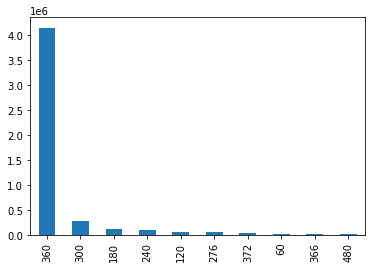

In [10]:
term_filt = income_filt[income_filt.loan_term != "Exempt"]

top_terms = (term_filt['loan_term'].value_counts()).iloc[:10]
top_terms.plot(kind='bar')



The 360 month (30 year) mortgage is by far the most popular, followed by the 25 and the 15 year mortgages.  

#### 4. Gender Histogram
For this one, the *Think Stats* histogram code can be used.

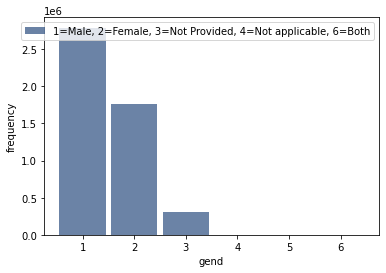

<Figure size 576x432 with 0 Axes>

In [11]:
hist_gend = thinkstats2.Hist(term_filt.applicant_sex, label = '1=Male, 2=Female, 3=Not Provided, 4=Not applicable, 6=Both')
thinkplot.Hist(hist_gend)
thinkplot.Show(xlabel = 'gend', ylabel = 'frequency')

In [12]:
hist_gend

Hist({1: 2790163, 2: 1755924, 3: 309930, 6: 2763, 4: 1236}, '1=Male, 2=Female, 3=Not Provided, 4=Not applicable, 6=Both')

We can see that there are a good deal more male than female applicants.  Our data is showing the 'first applicant' on an application, so maybe there is just a tendency for the male to list their name first.  We would need to bring in different data from the table to explore that hypothesis, though.

#### 5. Loan Amount
Our last variable to explore will be Loan Amount.  Similar to Income, we'll need to set a range, because of the expensive applications at the upper end.  We'll limit it to loans under \\$1million, which gives us a good picture of the shape of the data.  *Think Stats* histogram code is used here.

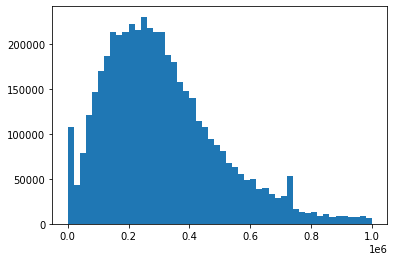

In [13]:
hist_loan = thinkstats2.Hist(term_filt.loan_amount, label = 'Loan Amount')
#income_filt = age_filt[age_filt.income >0]

plt.hist(term_filt.loan_amount, bins=50, range=[0, 1000000])
plt.show()


In [14]:
print("mean:", term_filt.loan_amount.mean(), "median:", term_filt.loan_amount.median(), "mode:", term_filt.loan_amount.mode())
print("variance:", term_filt.loan_amount.var(), "s.d.", term_filt.loan_amount.std())
print("Min:", term_filt.loan_amount.min(), "Max:", term_filt.loan_amount.max(), 
      "Interquartile Range:", np.percentile(term_filt.loan_amount, 75)-np.percentile(term_filt.loan_amount, 25))
print("Q1:", np.percentile(term_filt.loan_amount, 25), "Q3:", np.percentile(term_filt.loan_amount, 75) )

mean: 341492.99096957705 median: 285000.0 mode: 0    205000
dtype: int32
variance: 149967338808.21988 s.d. 387256.16690792656
Min: 5000 Max: 290905000 Interquartile Range: 250000.0
Q1: 175000.0 Q3: 425000.0


As with income, the loan amounts have a long tail to the right, which pulls up the mean (\\$341K).  The Median (\\$285K) is a better measure of central tendency.  There is a lot of variance, and the standard deviation is over \\$387K.   

The lowest loan was for \\$5000 and the largest is for \\$291 million.  50\% of the loans fall between \\$175K and \\$425K.

Some interesting spikes to consider.  
1. There is a spike at the very left end, indicating that very small mortgage loans are popular.  This could be an interesting result to explore in future analysis.  Perhaps there is a tax break for mortgages that make it valuable to get one, even if for a small amount.
2. There is a spike at around loan levels of \\$750K.  This also happens to be the cutoff point for you to deduct your mortgage interest, so it looks like a popular amount for people to set for their loan amount.  
(Source: https://www.nerdwallet.com/article/taxes/mortgage-interest-rate-deduction#:~:text=You%20can%20deduct%20the%20mortgage,the%20limit%20drops%20to%20%24375%2C000.)

### 4. PMF Comparison

Our next task is to compare the PMF for a variable based on two different scenarios.  The second histogram I did was a look at income ranges for people that applied for mortgages.  In that section, I was interested in if the distribution is different when we look at mortgages that ended up being completed (originated loans).  I'll run those scenareos here.

*Think Stats* recommended code used throughout.

In [15]:

income_filt["income_round"] = round(income_filt.income, -1)


orig_filt = income_filt[income_filt.action_taken == 1]
incomplete_filt = income_filt[income_filt.action_taken != 1]

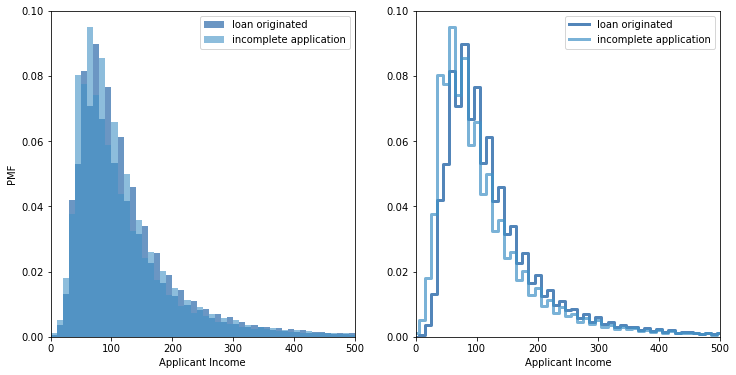

In [16]:
orig_pmf = thinkstats2.Pmf(orig_filt.income_round, label = "loan originated")
incomplete_pmf = thinkstats2.Pmf(incomplete_filt.income_round, label = "incomplete application")

width = 10
axis = [0, 500, 0, 0.1]
thinkplot.PrePlot(2, cols=2)
thinkplot.Hist(orig_pmf, align="right", width=width)
thinkplot.Hist(incomplete_pmf, align="left", width=width)
thinkplot.Config(xlabel="Applicant Income", ylabel="PMF", axis=axis)

thinkplot.PrePlot(2)
thinkplot.SubPlot(2)
thinkplot.Pmfs([orig_pmf, incomplete_pmf])
thinkplot.Config(xlabel="Applicant Income", axis=axis)

Looking at these two PMFs on top of each other we see evidence of what we might suspect.  The applicants that have higher income have a larger share of applications that went all the way through to loan origination, where as applicants with lower incomes have a comparatively larger portion of the applications that did not go all the way through, for one reason or another.

One of the reasons an application could be turned down would be because of a high debt to income ratio, so you could expect those with lower incomes to have a higher share of the rejected applications.

### 5. CDF of the Loan Amount

Now we will begin looking at the question we are addressing: whether loan amounts differ for elderly applicants.  
- We will use our "orig_filt" set, because it contains the applications that resulted in an originated loan.
- We'll set the axis to loans under \\$1 million because of the long tail.
- First, we'll look at the full population of originated loans.

*Think Stats* recommended code used throughout.

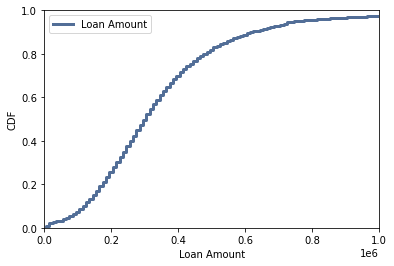

<Figure size 576x432 with 0 Axes>

In [17]:
all_loans_CDF = thinkstats2.Cdf(orig_filt.loan_amount, label='Loan Amount')

axis = [0, 1000000, 0, 1]

thinkplot.Cdf(all_loans_CDF)
thinkplot.Show(xlabel= 'Loan Amount', ylabel='CDF', axis=axis)

Visually, this looks about right.  We can see that the median appears to hit at loans arournd \\$300K.  This aligns with the histogram we did above of all loan applications.  (Median of loan applications was \\$285K.)

Next, we'll take a look at the CDF for those older than 62, versus those younger.

In [18]:
elder_filt = orig_filt[orig_filt.applicant_age_above_62 == "Yes"].copy(deep=True)
younger_filt = orig_filt[orig_filt.applicant_age_above_62 == "No"].copy(deep=True)

In [19]:
elder_cdf = thinkstats2.Cdf(elder_filt.loan_amount, label='Elder')
younger_cdf = thinkstats2.Cdf(younger_filt.loan_amount, label='Younger')

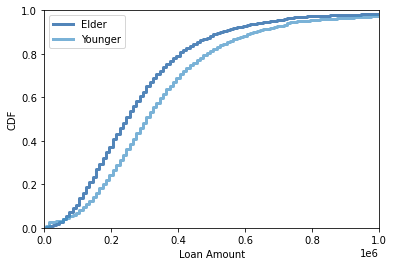

<Figure size 576x432 with 0 Axes>

In [20]:
thinkplot.PrePlot(2)
thinkplot.Cdfs([elder_cdf, younger_cdf])
thinkplot.Show(xlabel='Loan Amount', ylabel='CDF', axis=axis)

We can see clearly that elder applicants are more likely to pursue lower loan amounts.  From a visual look, you can see that about 40% of elderly mortgages were under \\$200K, while for younger applicants it's closer to 20%.

There could be several reasons for this.  One that I would like to explore is the question: "Are the loans smaller for the elderly because they're buying cheaper houses, or because they have more of a down payment?"  It could be that the elderly are selling old houses before they buy their new house, and are using the equity for a down payment.  Younger applicants are less likely to have equity accumulated.

To test this, we'll run CDFs on the property value.  This is our first time working with the property value field, so I'll need to remove any loans for which the property value is listed as "exempt" or "na".

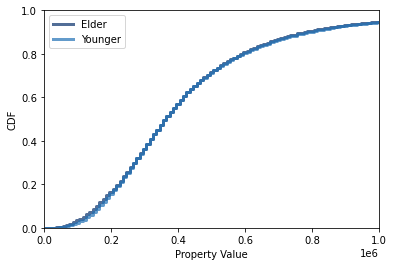

<Figure size 576x432 with 0 Axes>

In [21]:
prop_filt = orig_filt[orig_filt.property_value != "Exempt"].copy(deep=True)
prop_filt = prop_filt[prop_filt.property_value.isnull() == False].copy(deep=True)
prop_filt["prop_int"] = prop_filt["property_value"].astype(int)

elder_prop_filt = prop_filt[prop_filt.applicant_age_above_62 == "Yes"].copy(deep=True)
younger_prop_filt = prop_filt[prop_filt.applicant_age_above_62 == "No"].copy(deep=True)

elder_prop_cdf = thinkstats2.Cdf(elder_prop_filt.prop_int, label='Elder')
younger_prop_cdf = thinkstats2.Cdf(younger_prop_filt.prop_int, label='Younger')

thinkplot.Cdfs([elder_prop_cdf, younger_prop_cdf])
thinkplot.Show(xlabel='Property Value', ylabel='CDF', axis=axis)

We can see that the CDF for property value shows very little difference between elder and younger applicants.  So elderly applicants take out smaller loans, but do not tend to get less valuable homes, presumably because they tend to put more money down on the homes they buy.

There does appear to be a very slight difference when the houses are under \\$200K.  You can see that the darker line for elderly applicants is slightly above the line for the younger applicants.  A hypothesis test could help us determine if this difference is significant.

### 6. Fitting an analytical distribution

The distribution of property values appears to be normal.  We'll try to fit a normal model first.

In [22]:
print("mean:", prop_filt.prop_int.mean(), "median:", prop_filt.prop_int.median())
print("variance:", prop_filt.prop_int.var(), "s.d.", prop_filt.prop_int.std())

mean: 455696.1735452902 median: 365000.0
variance: 178185660141.37473 s.d. 422120.4332194483


Using the *Think Stats* text's functions, we can plot a normal distribution based on the mean and standard deviation of the actual data.  The Author's function trims some outliers, but there is a rather large right tail in this data set, so it may not be enough.

In [23]:
prop_val = prop_filt.prop_int

Mean, Var 433141.1111283813 77668337089.75801
Sigma 278690.39647924365


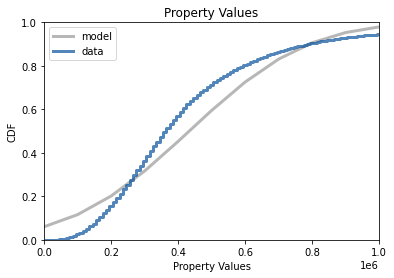

In [24]:
# estimate parameters: trimming outliers yields a better fit
mu, var = thinkstats2.TrimmedMeanVar(prop_val, p=0.01)
print("Mean, Var", mu, var)

# plot the model
sigma = np.sqrt(var)
print("Sigma", sigma)
xs, ps = thinkstats2.RenderNormalCdf(mu, sigma, low=0, high=10000000)

thinkplot.Plot(xs, ps, label="model", color="0.6")

# plot the data
cdf = thinkstats2.Cdf(prop_val, label="data")

thinkplot.PrePlot(1)
thinkplot.Cdf(cdf)
thinkplot.Config(title="Property Values", xlabel="Property Values", ylabel="CDF",
                axis = axis)

This fits somewhat, but doesn't capture the curve that well.  We'll chart a normal probability plot to see where the model deviates from the data, again using the *Think Stats* recommended code.

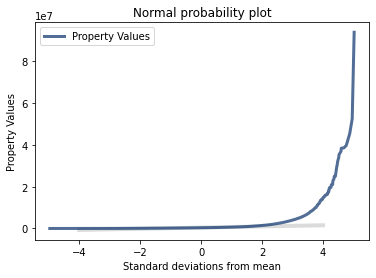

In [25]:
mean, var = thinkstats2.TrimmedMeanVar(prop_val, p=0.01)
std = np.sqrt(var)


xs = [-4, 4]
fxs, fys = thinkstats2.FitLine(xs, mean, std)
thinkplot.Plot(fxs, fys, linewidth=4, color="0.8")

xs, ys = thinkstats2.NormalProbability(prop_val)
thinkplot.Plot(xs, ys, label="Property Values")

thinkplot.Config(
    title="Normal probability plot",
    xlabel="Standard deviations from mean",
    ylabel="Property Values",
)

We can see that the normal model fits well until about two standard deviations from the mean.  After that, the model does not track the large house values in the right tail of the data.

We'll attempt a log-normal model to see if it improves the fit.

In [26]:
def MakeNormalModel(prop_val):
    """Plots a CDF with a Normal model.

    weights: sequence
    """
    cdf = thinkstats2.Cdf(prop_val, label="property value")

    mean, var = thinkstats2.TrimmedMeanVar(prop_val)
    std = np.sqrt(var)
    print("n, mean, std", len(prop_val), mean, std)

    xmin = mean - 4 * std
    xmax = mean + 4 * std

    xs, ps = thinkstats2.RenderNormalCdf(mean, std, xmin, xmax)
    thinkplot.Plot(xs, ps, label="model", linewidth=4, color="0.8")
    thinkplot.Cdf(cdf)

n, mean, std 2954249 5.562104660797243 0.25301028260983055


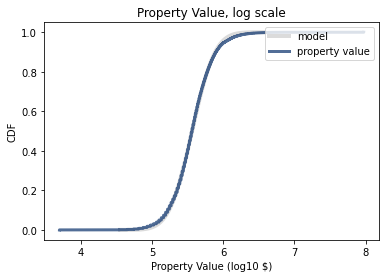

In [27]:
log_prop = np.log10(prop_val)
MakeNormalModel(log_prop)
thinkplot.Config(
    title="Property Value, log scale",
    xlabel="Property Value (log10 $)",
    ylabel="CDF",
    loc="upper right",
)

The Log-normal model fits the data much more closely.

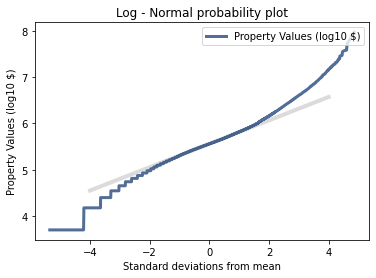

In [28]:
mean, var = thinkstats2.TrimmedMeanVar(log_prop, p=0.01)
std = np.sqrt(var)


xs = [-4, 4]
fxs, fys = thinkstats2.FitLine(xs, mean, std)
thinkplot.Plot(fxs, fys, linewidth=4, color="0.8")

xs, ys = thinkstats2.NormalProbability(log_prop)
thinkplot.Plot(xs, ys, label="Property Values (log10 $)")

thinkplot.Config(
    title="Log - Normal probability plot",
    xlabel="Standard deviations from mean",
    ylabel="Property Values (log10 $)",
)

Checking the Log-normal Probability plot, we can see that the Log-normal model fits the data much more closely than the normal model did.  There is still deviation from the model after 2 standard deviations, but it is not as extreme as the Normal Model.  The text mentions the possibility of fitting a second model for the tails.  If we were interested in predicting the larger deviations, it might be appropriate to test a secondary model for the tails, perhaps an exponential curve, considering how the data curves away from the lognormal probability plot.

### 7.  Scatter Plots and Correlation
So far in our hypothesis exploration, we have seen that elderly applicants tend to take on smaller mortgages, but there is not as big a difference (if any) in the value of the houses they buy.  At this point, we would like to explore the relationship between the age of the applicants and the mortgages they take on.  
- First, we can explore what looked like a strong relationship between age and loan value. 
- Second, we can explore the relationship between the age of the applicant and the debt they are willing to take on.  The data provides a "loan to value" ratio.  We'd expect to see that younger applicants take out higher loans compared to the value of the property, compared to elder applicants.

In our CDF exploration we explored age as a boolean (Older or younger than 62).  To test correlations, we will need to convert those ages into something closer to a continuous value.  We'll use the 7 'applicant_age' buckets and label them 0 through 6.  These values can be intuitively interpreted as "decades from age 15".  So a 24-year-old applicant can be described as 'age_bin' = 0, which means they're less than a decade removed from 15.

(I'm using np.select() for this binning task.  Source: https://www.dataquest.io/blog/tutorial-add-column-pandas-dataframe-based-on-if-else-condition/)

In [29]:
#Create a new dataframe with "age bins", zero through six.

age_bins = prop_filt.copy(deep=True)

conditions = [
    (age_bins["applicant_age"] == "<25"),
    (age_bins["applicant_age"] == "25-34"),
    (age_bins["applicant_age"] == "35-44"),
    (age_bins["applicant_age"] == "45-54"),
    (age_bins["applicant_age"] == "55-64"),
    (age_bins["applicant_age"] == "65-74"),
    (age_bins["applicant_age"] == ">74")
    ]

values = [0, 1, 2, 3, 4, 5, 6]

age_bins["age_bin"] = np.select(conditions, values)
    
age_bins.head()

,activity_year,loan_purpose,occupancy_type,loan_amount,action_taken,applicant_sex,applicant_age,applicant_age_above_62,income,combined_loan_to_value_ratio,loan_term,property_value,income_round,prop_int,age_bin
30,2023,1,1,5000,1,1,25-34,No,93.0,100.0,360,305000,90.0,305000,1
32,2023,1,1,5000,1,2,25-34,No,49.0,103.125,360,245000,50.0,245000,1
40,2023,1,1,645000,1,2,25-34,No,217.0,95.833,360,665000,220.0,665000,1
98,2023,1,1,375000,1,2,45-54,No,535.0,74.682,480,815000,540.0,815000,3
165,2023,1,1,565000,1,1,45-54,No,155.0,95.0,360,595000,160.0,595000,3


#### Age vs. Loan Value

We'll now use the text's recommended code to sample and jitter the data among the bin intervals.  Since the dataset is so large, we'll try looking at both a scatter plot and a hexbin plot.  We'll edit the *Think Stats* recommended code. 

In [30]:
sample = thinkstats2.SampleRows(age_bins, 5000)
loan_values, ages = sample.loan_amount, sample.age_bin

In [31]:
def Jitter(values, jitter =0.5):
    n = len(values)
    return np.random.uniform(-jitter, +jitter, n) + values

In [32]:
ages= Jitter(ages, .5)
loan_values = Jitter(loan_values, 500)

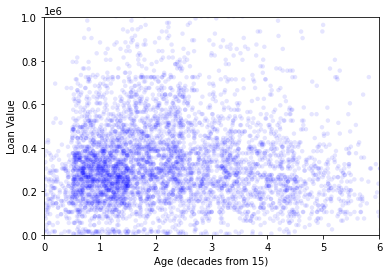

In [33]:
thinkplot.Scatter(ages, loan_values, alpha=0.1, s=20)
thinkplot.Config(xlabel='Age (decades from 15)',
                 ylabel='Loan Value',
                 axis=[0, 6, 0, 1000000],
                 legend=False)

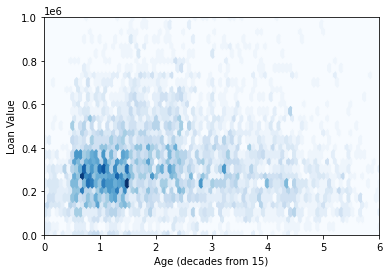

In [34]:
thinkplot.HexBin(ages, loan_values)
thinkplot.Config(xlabel='Age (decades from 15)',
                 ylabel='Loan Value',
                 axis=[0, 6, 0, 1000000],
                 legend=False)

#### Interpretation

Based on this, it is hard to spot the relationship we were expecting to see.  It may be the case that loan value goes up slightly as applicants move from their 20s into their 30s through 50s, and then falls back down again in the later decades.  If that's the case, then the regression models we will perform later might be the best fit because this relationship may be non-linear.  We'll use the *Think Stats* text code for our correlation statistics.

In [35]:
def Cov(xs, ys, meanx=None, meany=None):
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    if meanx is None:
        meanx = np.mean(xs)
    if meany is None:
        meany = np.mean(ys)

    cov = np.dot(xs-meanx, ys-meany) / len(xs)
    return cov

def Corr(xs, ys):
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    meanx, varx = thinkstats2.MeanVar(xs)
    meany, vary = thinkstats2.MeanVar(ys)

    corr = Cov(xs, ys, meanx, meany) / np.sqrt(varx * vary)
    return corr

In [36]:
Cov(age_bins.loan_amount, age_bins.age_bin)

10326.210559377385

In [37]:
Corr(age_bins.loan_amount, age_bins.age_bin)

0.026190823410693977

Our variance and our Pearson's Correlation value both indicate a positive correlation between age and loan amount.  The Pearson's Correlation of .026 indicates that the correlation overall is very small.  Since we saw what appeared to be a negative relationship between age and loan value at the elderly end of the age group, then there is likely an off-setting positive relationship in the earlier decades.  This indicates a non-linear relationship that we can explore further in our regression analysis.

#### Age vs Loan-to-value ratio

Since this is our first time using the "combined_loan_to_value_ratio", we will need to clean out the "exempt" and "NA" values.  Once the string values are removed from the field, we'll convert it to numeric.
(Source: https://stackoverflow.com/questions/25952790/convert-pandas-series-from-dtype-object-to-float-and-errors-to-nans)

In [38]:
LTV_filt = age_bins[age_bins.combined_loan_to_value_ratio != "Exempt"].copy(deep=True)
LTV_filt = LTV_filt[LTV_filt.combined_loan_to_value_ratio.isnull() == False].copy(deep=True)
LTV_filt["LTV_float"] = pd.to_numeric(LTV_filt.combined_loan_to_value_ratio, errors='coerce')

In [39]:
sample = thinkstats2.SampleRows(LTV_filt, 5000)
LTV, ages = sample.LTV_float, sample.age_bin

In [40]:
ages= Jitter(ages, .5)
# LTV is already a floating decimal and does not  need to be jittered.  
# Since we haven't worked with this variable yet, we'll run some stats and a histogram

In [41]:

print("Min:", LTV_filt.LTV_float.min(), "Max:", LTV_filt.LTV_float.max())

Min: 0.112 Max: 2075.412


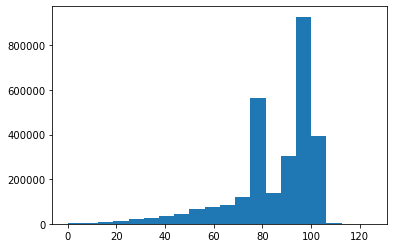

In [42]:

plt.hist(LTV_filt.LTV_float, bins=20, range=[0, 125])
plt.show()

Through these stats we see that the most typical LTV ratios are 80% and around 100%.  (80% makes sense.  That's the cutoff for PMI, at least in Ohio, where I live.)  Some houses are leveraged above the value of the property.  The max indicates that there is one property that is mortgaged to 20 times its value, (possibly a typo.)

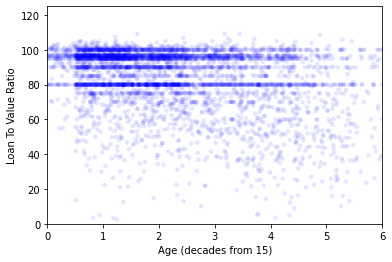

In [43]:
thinkplot.Scatter(ages, LTV, alpha=0.1, s=20)
thinkplot.Config(xlabel='Age (decades from 15)',
                 ylabel='Loan To Value Ratio',
                 axis=[0, 6, 0, 125],
                 legend=False)

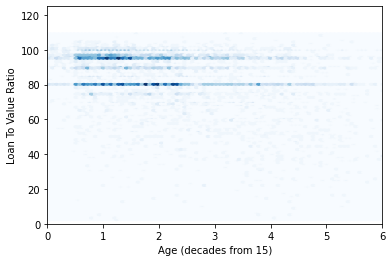

In [44]:
thinkplot.HexBin(ages, LTV)
thinkplot.Config(xlabel='Age (decades from 15)',
                 ylabel='Loan To Value Ratio',
                 axis=[0, 6, 0, 125],
                 legend=False)

#### Interpretation

The Scatterplot appears to show that younger applicants are more likely to have LTV ratios over 100, and as you get older, you see a tendency to lower LTVs.  The trend is faint to see, especially considering the prominence of 80%, 90%, 95% and 100% LTV mortgages.  But the general trend of the lighter dots does appear to go from upper left to lower right.

In [45]:
Cov(LTV_filt.LTV_float, LTV_filt.age_bin)

-7.4932025327955305

In [46]:
Corr(LTV_filt.LTV_float, LTV_filt.age_bin)

-0.3157716685446594

As expected from our visual examination of the scatterplots, the LTV ratio has a negative relationship with the age of the applicant.  As you get older, you tend to take on mortgages with lower LTV ratios.  The Pearson's correlation value of -.316 shows a much stronger correlation than what we saw between age and loan value.

### 8. Hypothesis Test

When we were ploting CDF of property value, we saw one result where elder and younger applicants appeared to have almost identical CDFs.  There was just a slight differnce in the lines at the lower property values.  Is the small difference between the CDF of property values observed between elderly and younger applicants significant?  We'll do a difference in means test to see if there is significance.  Since our hypothesis is that the difference occurs with lower home values, we'll filter our data to homes that are \\$300K or less, the area in the CDF where we see the difference.  Intuitively, we can argue that after a certain value of house, the applicant is probably wealthy enough such that their age doesn't effect their home-buying choices.

In [47]:
Sub300_elder_filt = elder_prop_filt[elder_prop_filt.prop_int < 300000].copy(deep=True)
Sub300_younger_filt = younger_prop_filt[younger_prop_filt.prop_int < 300000].copy(deep=True)
print(Sub300_elder_filt.prop_int.mean(), Sub300_younger_filt.prop_int.mean())

201095.9760059985 206638.1037375357


- The observed difference in means is only about $5500.  This is our test statistic.
- The null hypothesis is that this difference is not real.

First, we'll bring in the *Think Stats* text's code for Hypothesist Testing.

In [48]:
class HypothesisTest(object):

    def __init__(self, data):
        self.data = data
        self.MakeModel()
        self.actual = self.TestStatistic(data)

    def PValue(self, iters=1000):
        self.test_stats = [self.TestStatistic(self.RunModel()) 
                           for _ in range(iters)]

        count = sum(1 for x in self.test_stats if x >= self.actual)
        return count / iters

    def TestStatistic(self, data):
        raise UnimplementedMethodException()

    def MakeModel(self):
        pass

    def RunModel(self):
        raise UnimplementedMethodException()
        
class DiffMeansPermute(thinkstats2.HypothesisTest):

    def TestStatistic(self, data):
        group1, group2 = data
        test_stat = abs(group1.mean() - group2.mean())
        return test_stat

    def MakeModel(self):
        group1, group2 = self.data
        self.n, self.m = len(group1), len(group2)
        self.pool = np.hstack((group1, group2))

    def RunModel(self):
        np.random.shuffle(self.pool)
        data = self.pool[:self.n], self.pool[self.n:]
        return data

Next, we create the data frames.

In [49]:
data = Sub300_elder_filt.prop_int, Sub300_younger_filt.prop_int

In [50]:
ht = DiffMeansPermute(data)
pvalue = ht.PValue()
pvalue

0.0

A p_value of 0 means we should reject the null hypothesis.  Just to be certain, I'll use the scipy formula to get a more precise p_value.
(Source: https://builtin.com/data-science/t-test-python)

In [51]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(Sub300_elder_filt.prop_int, Sub300_younger_filt.prop_int)

print("p_value:", p_value)


p_value: 3.1971676105114673e-161


Using this method, we can see just how low the p_value is.  Knowing this, we can say that the effect on the difference in means is statistically significant, even though it is a small effect.

### 9. Regression Analysis

In our correlation work we saw that the relationship between age and loan value did not appear to be linear.  We suspected that loan values might raise through the early decades and fall in later decades.  This might suggest a quadratic model for the relationship.  First we will try a linear model, so that we have something we can use to compare.  We'll set our threshold (alpha) at the standard .05.  Any p-values below this will be considered significant.

In [52]:
import statsmodels.formula.api as smf
formula = 'loan_amount ~ age_bin'
results = smf.ols(formula, data=age_bins).fit()
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            loan_amount   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2028.
Date:                Sat, 01 Jun 2024   Prob (F-statistic):               0.00
Time:                        22:51:09   Log-Likelihood:            -4.1291e+07
No. Observations:             2954249   AIC:                         8.258e+07
Df Residuals:                 2954247   BIC:                         8.258e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.443e+05    303.641   1133.891      0.000    3.44e+05    3.45e+05
age_bin     5372.8585    119.312     45.032      0.000    5139.011    5606.706
==============================================================================
Omnibus:                  3886654.363   Durbin-Watson:                   1.590
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       4422530663.741
Skew:                           6.781   Prob(JB):                         0.00
Kurtosis:                     192.061   Cond. No.                         5.20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Interpretation

Our linear model shows that age_bin has a 0.0 P_value, giving us confidence that there is a correlation.  However, the R-Squared value is very low (.001), meaning that age of applicant age only explains a very small part of the observed changes in loan_amount.

Next, we'll add a quadratic variable to our model.

In [53]:
age_bins["age_bin2"] = age_bins.age_bin**2


formula = 'loan_amount ~ age_bin + age_bin2'
results = smf.ols(formula, data=age_bins).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            loan_amount   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                 4.007e+04
Date:                Sat, 01 Jun 2024   Prob (F-statistic):               0.00
Time:                        22:51:10   Log-Likelihood:            -4.1252e+07
No. Observations:             2954249   AIC:                         8.250e+07
Df Residuals:                 2954246   BIC:                         8.250e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.492e+05    453.612    549.290      0.000    2.48e+05     2.5e+05
age_bin     1.112e+05    396.733    280.338      0.000     1.1e+05    1.12e+05
age_bin2   -2.019e+04     72.266   -279.388      0.000   -2.03e+04      -2e+04
==============================================================================
Omnibus:                  3930397.228   Durbin-Watson:                   1.602
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       4832096916.281
Skew:                           6.911   Prob(JB):                         0.00
Kurtosis:                     200.647   Cond. No.                         37.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Interpretation

The p-value remains below our threshold, and the R-squared has improved.  Our model now accounts for 2.6% of the variability in loan_amount.  

The coefficients support our intuitive guess on the shape of the relationship.  age_bin is positive and age_bin2 is negative.  That means that when age is young, the combined coeficients will be positive, causing loan_amount to rise as age increases.  Eventually, though, age_bin2's coefficient will surpass the influence of age_bin's coefficient, and the effect of increasing age in the model will be to decrease the estimate loan_amount.  The model reflects the "rise then fall" pattern we had in mind.

We have demonstrated the relationship between age and loan_amount that we expected to see.  However, this model only predicts a small portion of the variability in loan_amount.  To tie all or our exploratory data analysis together, we should try to add another variable that we analyzed earlier: income.  

We'll try both the linear and the quadratic for income.  A non-linear model for income may make sense, because low income applicants probably don't borrow a lot, but high income applicants may not need to borrow a lot.  So there may be a rise and fall on the income relationship similar to age.

In [54]:
formula = 'loan_amount ~ age_bin + age_bin2 + income'
results = smf.ols(formula, data=age_bins).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            loan_amount   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                 1.640e+05
Date:                Sat, 01 Jun 2024   Prob (F-statistic):               0.00
Time:                        22:51:12   Log-Likelihood:            -4.1064e+07
No. Observations:             2954249   AIC:                         8.213e+07
Df Residuals:                 2954245   BIC:                         8.213e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.242e+05    427.467    524.472      0.000    2.23e+05    2.25e+05
age_bin     9.595e+04    373.052    257.207      0.000    9.52e+04    9.67e+04
age_bin2   -1.766e+04     67.928   -259.938      0.000   -1.78e+04   -1.75e+04
income       286.8391      0.453    633.238      0.000     285.951     287.727
==============================================================================
Omnibus:                  5075374.795   Durbin-Watson:                   1.639
Prob(Omnibus):                  0.000   Jarque-Bera (JB):    1591474522990.426
Skew:                         -10.082   Prob(JB):                         0.00
Kurtosis:                    3598.631   Cond. No.                     1.33e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.33e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [55]:
age_bins["income2"] = age_bins.income**2

formula = 'loan_amount ~ age_bin + age_bin2 + income + income2'
results = smf.ols(formula, data=age_bins).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            loan_amount   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                 2.899e+05
Date:                Sat, 01 Jun 2024   Prob (F-statistic):               0.00
Time:                        22:51:14   Log-Likelihood:            -4.0803e+07
No. Observations:             2954249   AIC:                         8.161e+07
Df Residuals:                 2954244   BIC:                         8.161e+07
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.919e+05    393.561    487.624      0.000    1.91e+05    1.93e+05
age_bin      7.67e+04    342.385    224.007      0.000     7.6e+04    7.74e+04
age_bin2   -1.445e+04     62.316   -231.885      0.000   -1.46e+04   -1.43e+04
income       656.4221      0.641   1024.529      0.000     655.166     657.678
income2       -0.0030   4.01e-06   -756.580      0.000      -0.003      -0.003
==============================================================================
Omnibus:                  3059911.991   Durbin-Watson:                   1.669
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     106514818500.958
Skew:                          -3.437   Prob(JB):                         0.00
Kurtosis:                     933.198   Cond. No.                     1.95e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.95e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Interpretation

As we theorized, adding income to the model improved it's effectiveness.  With the R-squared going up to 14%.  Adding in the squared income as a variable improved the model even further, and our model explains about 28% of the variability in loan_amount.  All variables have very low P_values, and thus are significant correlations with loan_amount.

The coefficients for income and income2 support our theory that there is a rise and fall effect for income, similar to age.  The positive coefficient for 'income' will drive the predicted loan_amount up as incomes increase, at first, until the 'income2' gets big enough.  At that point, the negative coefficient for 'income2' will counteract the positive influence of 'income' and 'income2' will bring the loan_amount down.

# Concluding Essay

### Hypothesis
This exploratory data analysis posited the hypothesis that elder applicants for mortgages behave differently than younger applicants.  In particular, we hypothesized that loan amounts and property values would be lower as elder applicants cashed in on equity in their old houses and “moved down” into a smaller house.

### Outcome
Our CDF analysis showed a visible difference in loan amounts, and a very small difference in property values.  A hypothesis test confirmed that this small difference in property values was significant.  We considered that the Boolean nature of the “over 62” field might be masking a more complicated relationship between age and loan amount.  We used scatterplots to attempt to visually see the relationship, and then used a multi-variable regression analysis to plot a quadratic model that accounted for 28% of the variability in loan amount.

### What Was Missed
Our analysis didn’t consider any of the economic issues affecting the housing market in 2023, particularly the rise in interest rates.  There was also demographic data that could have been considered.  The differences we demonstrated may have had more to do with the shock of higher mortgage rates having an outsized effect on one cohort or another, or an outsized effect on a demographic group (racial, ethnic, etc.) that was not considered.

### Other Variables
The date of the mortgage might have been useful.  The housing market is cyclical, with more home buying happening in the summer months.  It could have been helpful to control for date, if perhaps one cohort is more likely to shop in the summer, when demand is higher, and LTV might presumably be higher as well.

### Incorrect Assumptions
I incorrectly assumed that I knew what the “Combined Loan to Value Ratio” was.  I started seeing LTVs that did not correspond to the ratio between the loan amount and the property value.  Then, I finally researched the term and realized that “combined” means all debt on the property, not just this particular mortgage.

### Challenges
I struggled a lot early on getting the data into a format that could be used, particularly for the histograms, which I expected to be one of the easier sections to do.  I quickly realized that the book’s histogram code only works for certain data types, and that I needed to expand into other sources.  As I progressed through the project, the data got cleaner, and I got more skilled with managing it.
Fitting the normal and lognormal models were a challenge.  If I could account for skew and kurtosis better, I would have gotten a better fit.
I still feel that I do not fully understand the statistics around regression.  The list of information is long, and I only use a few of the numbers.
Overall, I felt this project challenge both my coding abilities and my mathematical understanding of the statistics and models that we use in data science.


# References

Sources to websites referenced throughout this document indicate sources of inspiration for the coding techniques used.  
Text book code references come from the author's publicly available github repository for use in our class.

#### Course Text Book:
Downey, Allen B. (2015). *Think Stats*(2nd ed.). O'Reily.

#### Project Data Source:

Consumer Financial Protection Bureau (2024). *Home Mortgage Disclosure Act: Modified Loan/Application Register (LAR).* Federal Financial Institutions Examination Council (FFIEC). https://ffiec.cfpb.gov/data-publication/modified-lar/2023